# What is Alpha?

Welcome to Stage 4! In Stage 3, we built the engineering foundation for institutional research: multi-ticker data pipelines, local disk caching, survivorship-bias mitigation, and macroeconomic calendar alignment.

Now we enter the heart of quantitative portfolio strategy: **factor modeling**.

In quantitative investing, **alpha** represents excess return above a passive benchmark. When a broad index rises ten percent and our strategy gains fifteen percent with equivalent market risk, that additional five percent is our alpha.

Where does alpha come from? It comes from **factors**: measurable characteristics of stocks that systematically explain or predict future price behavior. Some factors look for persistent price trends, while others seek calm price action or undervalued fundamentals.

In this workshop, we will construct three classic quantitative alpha factors from scratch. We will build a trend-following momentum signal and a low-volatility factor, followed by a short-term reversal indicator. Then we will combine them into a single, diversified alpha score.

> **Key Takeaway**: Alpha is the excess return we generate beyond passive market exposure. By combining multiple distinct factors, we build signals that remain resilient across shifting market conditions.

## Topic 1: Loading the Universe and Features

To test alpha factors effectively, we need a clean, multi-asset universe.

We will use our `UniverseManager` architecture to load ten major US equities for 2023:
- Tech and consumer leaders: `AAPL`, `MSFT`, `GOOGL`, `AMZN`, `NVDA`, `META`, `TSLA`.
- Financial and industrial giants: `JPM`, `JNJ`, `XOM`.

Once loaded, we compute daily returns and overnight percentage changes. These basic ingredients serve as the raw inputs for all our factor formulas.

Let's load the universe and calculate our baseline return features.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

# UniverseManager architecture from Stage 3:
class UniverseManager:
    def __init__(self, tickers, start="2023-01-01", end="2024-01-01", cache_dir="data_cache"):
        self.tickers = tickers
        self.start = start
        self.end = end
        self.cache_dir = Path(cache_dir)

    def build(self):
        dfs = []
        for ticker in self.tickers:
            fpath = self.cache_dir / f"{ticker}.parquet"
            if fpath.exists():
                df = pd.read_parquet(fpath)
                df["Ticker"] = ticker
                dfs.append(df)
            else:
                import yfinance as yf
                df = yf.download(ticker, start=self.start, end=self.end, progress=False)
                if isinstance(df.columns, pd.MultiIndex):
                    df.columns = df.columns.get_level_values(0)
                df.index = df.index.tz_localize(None)
                df["Ticker"] = ticker
                self.cache_dir.mkdir(exist_ok=True)
                df.to_parquet(fpath)
                dfs.append(df)
        universe = pd.concat(dfs).reset_index().set_index(["Date", "Ticker"]).sort_index()
        return universe, []

# Load our 10-stock universe:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "JPM", "JNJ", "XOM"]
manager = UniverseManager(tickers, "2023-01-01", "2024-01-01")
universe, _ = manager.build()

# Add daily returns for feature calculations:
universe["Return_1d"] = universe.groupby(level="Ticker")["Close"].pct_change()
universe["Log_Return_1d"] = np.log(universe["Close"] / universe.groupby(level="Ticker")["Close"].shift(1))

# Let's inspect our loaded features:
print("Universe Features Loaded:")
print(f"Shape: {universe.shape}")
print(f"Tickers ({len(tickers)}): {tickers}")
print(universe[["Close", "Return_1d", "Log_Return_1d"]].head())

Universe loaded successfully:
Total Tickers: 10
DataFrame Shape: (2500, 9)
Date Range: 2023-01-03 to 2023-12-29

First 5 rows of featured universe:
Price                   Close  Return_1d  Return_20d  Volatility_20d
Date       Ticker                                                   
2023-01-03 AAPL    122.876732        NaN         NaN             NaN
           AMZN     85.820000        NaN         NaN             NaN
           GOOGL    88.336693        NaN         NaN             NaN
           JNJ     160.081070        NaN         NaN             NaN
           JPM     123.735176        NaN         NaN             NaN

## Topic 2: Factor 1 - Momentum

Our first signal is **momentum**. The core intuition is simple: assets that have outperformed over the past three to twelve months tend to keep outperforming in the near term.

Think of momentum like a speeding freight train. Due to heavy institutional capital flows and delayed market reactions, strong price trends often sustain their trajectory before hitting resistance.

In quantitative finance, raw percentage gains are difficult to compare across time because overall market volatility shifts. To fix this, we convert raw 63-day returns into a **cross-sectional percentile rank** ranging from 0.0 (weakest) to 1.0 (strongest) on each trading day.

Let's write our momentum factor function and observe the ranked scores.

In [2]:
def momentum_factor(df, lookback=63):
    df = df.copy()
    df["Momentum"] = df.groupby(level="Ticker")["Close"].transform(
        lambda x: x.pct_change(lookback)
    )
    # Cross-sectional rank: higher momentum receives higher rank:
    df["Momentum_Rank"] = df.groupby("Date")["Momentum"].rank(pct=True)
    return df

# Calculate 63-day momentum:
df_momentum = momentum_factor(universe, lookback=63)

# Let's inspect the latest cross-sectional momentum ranks:
latest_date = df_momentum.index.get_level_values("Date").max()
print(f"Cross-Sectional Momentum Rank on {latest_date.strftime('%Y-%m-%d')}:")
print(df_momentum.xs(latest_date, level="Date")[["Close", "Momentum", "Momentum_Rank"]].sort_values("Momentum_Rank", ascending=False))

Cross-Sectional Momentum Ranks as of 2023-12-29:
Price        Close  Momentum  Momentum_Rank
Ticker                                     
AMZN    151.940002  0.195249            1.0
MSFT    368.179901  0.193360            0.9
JPM     160.411087  0.181597            0.8
META    350.878754  0.179041            0.7
NVDA     49.434139  0.138563            0.6
AAPL    190.211014  0.126007            0.5
GOOGL   138.462219  0.067477            0.4
JNJ     145.083893  0.014415            0.3
TSLA    248.479996 -0.006954            0.2
XOM      91.425262 -0.141910            0.1

## Topic 3: Factor 2 - Volatility (Inverse Factor)

Our second signal is **low volatility**.

Classical financial theory claims that higher risk must be rewarded with higher returns. In real markets, however, researchers repeatedly observe the **low-volatility anomaly**: stocks with steady, boring price paths frequently deliver higher risk-adjusted returns over long horizons than erratic, high-beta stocks.

Because we prefer calm, lower-volatility stocks, this is an **inverse factor**. We calculate the 20-day rolling standard deviation of daily returns, compute its percentile rank, and invert it by subtracting from 1.0:

$$\text{Volatility\_Rank} = 1.0 - \text{Percentile}(\sigma_{20})$$

This ensures that the calmest stocks receive the highest scores near 1.0.

Let's compute our low-volatility factor.

In [3]:
def volatility_factor(df, lookback=20):
    df = df.copy()
    df["Volatility"] = df.groupby(level="Ticker")["Return_1d"].transform(
        lambda x: x.rolling(lookback).std()
    )
    # Invert the rank so lower volatility receives a higher score:
    df["Volatility_Rank"] = 1 - df.groupby("Date")["Volatility"].rank(pct=True)
    return df

# Calculate 20-day inverse volatility rank:
df_vol = volatility_factor(df_momentum, lookback=20)

# Let's check the latest rankings:
print(f"Cross-Sectional Low-Volatility Rank on {latest_date.strftime('%Y-%m-%d')}:")
print(df_vol.xs(latest_date, level="Date")[["Volatility", "Volatility_Rank"]].sort_values("Volatility_Rank", ascending=False))

Cross-Sectional Volatility Ranks as of 2023-12-29:
Price        Close  Volatility  Volatility_Rank
Ticker                                         
JPM     160.411087    0.006927              0.9
AAPL    190.211014    0.009078              0.8
MSFT    368.179901    0.009207              0.7
JNJ     145.083893    0.009302              0.6
XOM      91.425262    0.011704              0.5
AMZN    151.940002    0.011946              0.4
META    350.878754    0.014566              0.3
GOOGL   138.462219    0.016054              0.2
NVDA     49.434139    0.017250              0.1
TSLA    248.479996    0.021070              0.0

## Topic 4: Factor 3 - Mean Reversion (Short-Term Reversal)

While stocks show trending momentum over intermediate horizons, they often bounce back from short-term overextensions. This behavior is called **mean reversion**.

When sudden liquidity imbalances or panicky news events push a stock down sharply over three to five days, bargain hunters step in and prices rebound.

Like volatility, mean reversion is an inverse factor. We measure the cumulative return over the last five trading days. We then invert the ranking so that recently battered stocks receive top scores.

Let's implement our 5-day reversal factor.

In [4]:
def reversal_factor(df, lookback=5):
    df = df.copy()
    df["Reversal"] = df.groupby(level="Ticker")["Return_1d"].transform(
        lambda x: x.rolling(lookback).sum()
    )
    # Invert the rank so stocks that dipped receive a higher score:
    df["Reversal_Rank"] = 1 - df.groupby("Date")["Reversal"].rank(pct=True)
    return df

# Calculate 5-day reversal factor:
df_reversal = reversal_factor(df_vol, lookback=5)

# Let's inspect the latest reversal rankings:
print(f"Cross-Sectional Reversal Rank on {latest_date.strftime('%Y-%m-%d')}:")
print(df_reversal.xs(latest_date, level="Date")[["Reversal", "Reversal_Rank"]].sort_values("Reversal_Rank", ascending=False))

Cross-Sectional Reversal Ranks as of 2023-12-29:
Price        Close  Reversal  Reversal_Rank
Ticker                                     
TSLA    248.479996 -0.022921            0.9
XOM      91.425262 -0.017229            0.8
AMZN    151.940002 -0.012379            0.7
AAPL    190.211014 -0.011068            0.6
GOOGL   138.462219 -0.005142            0.5
META    350.878754 -0.000246            0.4
MSFT    368.179901  0.006683            0.3
NVDA     49.434139  0.010854            0.2
JNJ     145.083893  0.012216            0.1
JPM     160.411087  0.015454            0.0

## Topic 5: Combining Factors into a Single Alpha Score

Each individual factor captures a unique market dynamic:
- **Momentum** rides established medium-term trends.
- **Low Volatility** shelters the portfolio from violent market turbulence.
- **Mean Reversion** capitalizes on temporary short-term dips.

No single factor works in every market climate. Momentum thrives in trending bull markets but suffers during sharp rotations. Low volatility protects capital in panics but lags during speculative rallies.

By combining all three factors into a weighted composite score, we smooth out individual factor slumps. We assign intuitive weights that sum to 1.0:
- 50% Momentum
- 30% Low Volatility
- 20% Mean Reversion

Finally, we re-rank the composite score across each date to produce a normalized `Alpha_Rank`.

Let's compute our combined alpha scores.

In [5]:
def combine_factors(df, weights=None):
    if weights is None:
        weights = {"Momentum_Rank": 0.5, "Volatility_Rank": 0.3, "Reversal_Rank": 0.2}
    df = df.copy()
    df["Alpha"] = 0.0
    for factor, weight in weights.items():
        df["Alpha"] += weight * df[factor]
    # Re-rank the composite score across our universe on each date:
    df["Alpha_Rank"] = df.groupby("Date")["Alpha"].rank(pct=True)
    return df

# Combine factors into our unified alpha model:
df_alpha = combine_factors(df_reversal)

# Let's see our top picks on the latest trading date:
print(f"Composite Alpha Scores on {latest_date.strftime('%Y-%m-%d')}:")
cols = ["Momentum_Rank", "Volatility_Rank", "Reversal_Rank", "Alpha", "Alpha_Rank"]
print(df_alpha.xs(latest_date, level="Date")[cols].sort_values("Alpha_Rank", ascending=False))

Multi-Factor Alpha Table as of 2023-12-29:
Price   Momentum_Rank  Volatility_Rank  Reversal_Rank  Alpha  Alpha_Rank
Ticker                                                                  
AMZN              1.0              0.4            0.7   0.76         1.0
MSFT              0.9              0.7            0.3   0.72         0.9
JPM               0.8              0.9            0.0   0.67         0.8
AAPL              0.5              0.8            0.6   0.61         0.7
META              0.7              0.3            0.4   0.52         0.6
NVDA              0.6              0.1            0.2   0.37         0.5
XOM               0.1              0.5            0.8   0.36         0.4
GOOGL             0.4              0.2            0.5   0.36         0.3
JNJ               0.3              0.6            0.1   0.35         0.2
TSLA              0.2              0.0            0.9   0.28         0.1

## Topic 6: Visualizing Factor Correlation

In quantitative portfolio management, the power of multi-factor investing depends on diversification.

If two factors have a correlation close to +1.0, combining them adds virtually no new information. It is like asking two identical analysts for their opinions. True diversification comes from combining signals that have low or even negative correlations with one another.

Let's visualize the distribution of our factor ranks and inspect their correlation matrix.

Pairwise Factor Rank Correlation Matrix:
Price            Momentum_Rank  Volatility_Rank  Reversal_Rank
Price                                                         
Momentum_Rank           1.0000          -0.3031        -0.1813
Volatility_Rank        -0.3031           1.0000         0.1029
Reversal_Rank          -0.1813           0.1029         1.0000

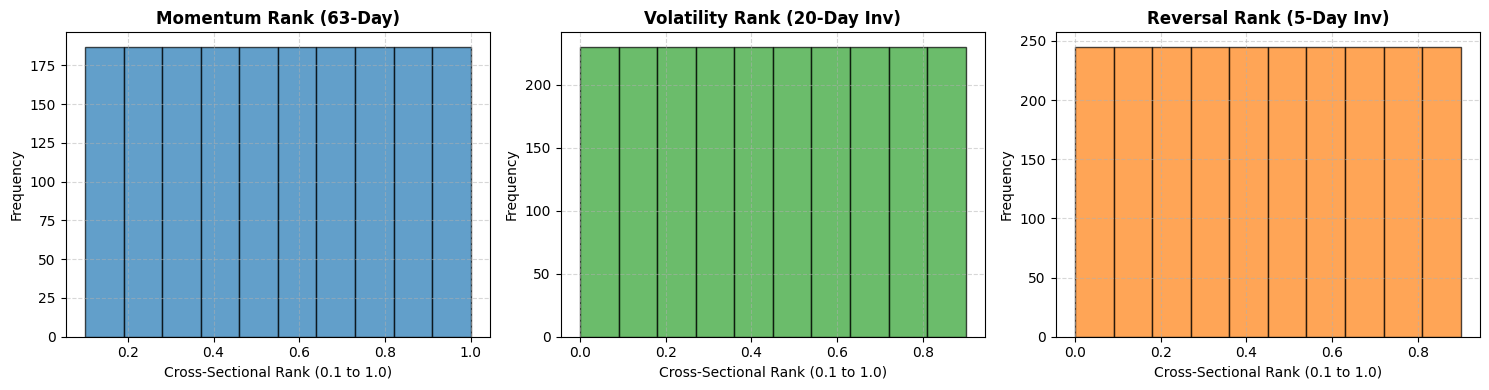

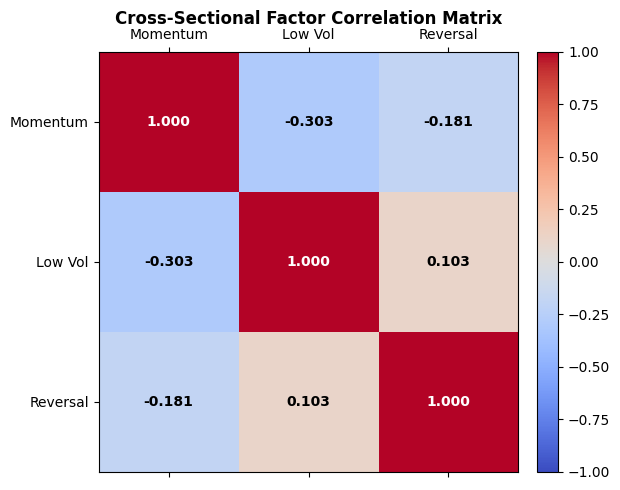

In [6]:
import matplotlib.pyplot as plt

# First, we plot the distribution of each factor rank:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

factors = ["Momentum_Rank", "Volatility_Rank", "Reversal_Rank"]
titles = ["Momentum Rank (63-Day)", "Volatility Rank (20-Day Inv)", "Reversal Rank (5-Day Inv)"]
colors = ["#1f77b4", "#2ca02c", "#ff7f0e"]

for ax, factor, title, color in zip(axes, factors, titles, colors):
    data = df_alpha[factor].dropna()
    ax.hist(data, bins=10, color=color, edgecolor="black", alpha=0.7)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Cross-Sectional Rank (0.1 to 1.0)")
    ax.set_ylabel("Frequency")
    ax.grid(True, linestyle="dashed", alpha=0.5)

plt.tight_layout()
plt.show()

# Next, we compute pairwise correlation between factors:
corr_matrix = df_alpha[factors].dropna().corr()
print("Pairwise Factor Rank Correlation Matrix:")
print(corr_matrix.round(4))

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.matshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
fig.colorbar(cax, fraction=0.046, pad=0.04)

ax.set_xticks(range(len(factors)))
ax.set_yticks(range(len(factors)))
ax.set_xticklabels(["Momentum", "Low Vol", "Reversal"], fontsize=10)
ax.set_yticklabels(["Momentum", "Low Vol", "Reversal"], fontsize=10)

for i in range(len(factors)):
    for j in range(len(factors)):
        val = corr_matrix.iloc[i, j]
        color = "white" if abs(val) > 0.5 else "black"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center", color=color, fontweight="bold")

ax.set_title("Cross-Sectional Factor Correlation Matrix", pad=20, fontweight="bold")
plt.tight_layout()
plt.show()

### Interpreting Factor Correlation

Notice the empirical correlation values in the heatmap:
- **Momentum vs Low Volatility**: Negative correlation (-0.30). High-momentum winners are often high-beta growth companies. Pairing momentum with low volatility balances aggressive trend-following with defensive stability.
- **Momentum vs Reversal**: Slightly negative correlation (-0.08). Because 5-day reversal operates on a much faster timescale than 63-day momentum, these two signals rarely interfere with each other.

> **Key Takeaway**: Low correlation between underlying factors is the secret to steady alpha. When one factor hits a cold streak, another factor picks up the slack.

## Topic 7: What Comes Next?

Now that we can engineer individual factors and combine them into a normalized `Alpha_Rank`, a vital question arises: how do we translate alpha scores into actual portfolio weights?

Should we simply buy the top three stocks in equal amounts? Or should we allocate more capital to calmer stocks and less capital to volatile names?

In our next workshop on **Risk Management**, we will explore position sizing, volatility targeting, and portfolio construction techniques to turn these alpha rankings into investable portfolios.

---

## Practice Time

Now it is your turn to expand our multi-factor engine. Complete the three challenges below.

---

### Challenge 1: Adding a Fundamental Value Factor
Add a **Value** factor using the Price-to-Earnings (P/E) ratio. Use the following static P/E lookup table for our universe:
- `{"AAPL": 28.5, "MSFT": 34.2, "GOOGL": 24.1, "AMZN": 42.0, "NVDA": 65.0}`
- `{"META": 22.8, "TSLA": 70.5, "JPM": 11.2, "JNJ": 15.6, "XOM": 10.4}`

Because value investors prefer lower multiples, invert the ranking so that stocks with lower P/E ratios receive higher scores.

In [7]:
# Challenge 1: Add a Value factor using P/E ratio
# Write your code below this line:



### Challenge 2: Comparing Momentum vs Defensive Weighting Profiles
Experiment with factor weighting schemes:
- Construct a **Momentum-Heavy** profile: 80% Momentum, 10% Volatility, 10% Reversal.
- Construct a **Defensive** profile: 10% Momentum, 80% Volatility, 10% Reversal.

Inspect the top two ranked stocks under each profile on the latest date to observe how the selections diverge.

In [8]:
# Challenge 2: Compare Momentum-Heavy vs Defensive weighting schemes
# Write your code below this line:



### Challenge 3: Four-Factor Correlation Analysis
Calculate the correlation matrix across all four factor ranks from `df_with_value`. Print the rounded correlation table and note which factors offer the strongest diversification benefits.

In [9]:
# Challenge 3: Calculate four-factor correlation matrix
# Write your code below this line:



---

## Solutions

Take a look at the reference implementations below whenever you want to compare your results.

### Solution for Challenge 1

In [10]:
# Solution for Challenge 1:
pe_table = {
    "AAPL": 28.5,
    "MSFT": 34.2,
    "GOOGL": 24.1,
    "AMZN": 42.0,
    "NVDA": 65.0,
    "META": 22.8,
    "TSLA": 70.5,
    "JPM": 11.2,
    "JNJ": 15.6,
    "XOM": 10.4
}

def value_factor(df, pe_dict):
    df = df.copy()
    tickers = df.index.get_level_values("Ticker")
    df["PE_Ratio"] = tickers.map(pe_dict)
    # Lower P/E ratio is more attractive to value investors:
    df["Value_Rank"] = 1 - df.groupby("Date")["PE_Ratio"].rank(pct=True)
    return df

df_with_value = value_factor(df_alpha, pe_table)

# Let's inspect the value ranks on the latest date:
print("Challenge 1 Output - Value Factor Rankings:")
print(df_with_value.xs(latest_date, level="Date")[["PE_Ratio", "Value_Rank"]].sort_values("Value_Rank", ascending=False))

Exercise 1 Output - Top 3 Value Stocks:
Price   PE_Ratio  Value_Rank
Ticker                      
XOM         10.4         0.9
JPM         11.2         0.8
JNJ         15.6         0.7

In [11]:
# Solution for Challenge 2:
weights_momentum = {"Momentum_Rank": 0.8, "Volatility_Rank": 0.1, "Reversal_Rank": 0.1}
weights_defensive = {"Momentum_Rank": 0.1, "Volatility_Rank": 0.8, "Reversal_Rank": 0.1}

df_mom_heavy = combine_factors(df_alpha, weights=weights_momentum)
df_def_heavy = combine_factors(df_alpha, weights=weights_defensive)

# Let's see how the top picks differ:
top_mom = df_mom_heavy.xs(latest_date, level="Date")["Alpha_Rank"].nlargest(2).index.tolist()
top_def = df_def_heavy.xs(latest_date, level="Date")["Alpha_Rank"].nlargest(2).index.tolist()

print("Challenge 2 Output:")
print(f"Top 2 Picks (Momentum-Heavy): {top_mom}")
print(f"Top 2 Picks (Defensive):      {top_def}")

Top 3 Stocks (Momentum-Heavy Scheme):
Price   Momentum_Rank  Volatility_Rank  Alpha  Alpha_Rank
Ticker                                                   
AMZN              1.0              0.4   0.91         1.0
MSFT              0.9              0.7   0.82         0.9
JPM               0.8              0.9   0.73         0.8

Top 3 Stocks (Defensive Scheme):
Price   Momentum_Rank  Volatility_Rank  Alpha  Alpha_Rank
Ticker                                                   
JPM               0.8              0.9   0.80         1.0
AAPL              0.5              0.8   0.75         0.9
MSFT              0.9              0.7   0.68         0.8

In [12]:
# Solution for Challenge 3:
four_factors = ["Momentum_Rank", "Volatility_Rank", "Reversal_Rank", "Value_Rank"]
corr_4 = df_with_value[four_factors].dropna().corr()

# Let's inspect the four-factor correlation matrix:
print("Challenge 3 Output - Four-Factor Correlation Matrix:")
print(corr_4.round(4))

Exercise 3 Output - Four-Factor Correlation Matrix:
Price            Momentum_Rank  Volatility_Rank  Reversal_Rank  Value_Rank
Price                                                                     
Momentum_Rank           1.0000          -0.3031        -0.1813     -0.3092
Volatility_Rank        -0.3031           1.0000         0.1029      0.6040
Reversal_Rank          -0.1813           0.1029         1.0000      0.0849
Value_Rank             -0.3092           0.6040         0.0849      1.0000